# Análisis Exploratorio de Datos: Reingreso de Pacientes Diabéticos
### Contexto: 
Este dataset representa 10 años de atención clínica en 130 hospitales de EE. UU. El objetivo es predecir si un paciente será readmitido en menos de 30 días.

### Justificación de la IA: 
El uso de modelos de Machine Learning permite identificar patrones no lineales entre medicamentos, diagnósticos y antecedentes que un análisis humano pasaría por alto. Esto ayuda a los hospitales a priorizar recursos y mejorar la supervivencia del paciente.

In [19]:
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

# Bibliotecas de visualización
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


# Configuración de estilo
sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (14, 8)

print("✅ Librerías cargadas exitosamente")

✅ Librerías cargadas exitosamente


In [11]:
# ===============================================
# 1. CARGAR Y PREPARAR DATOS
# ===============================================

os.chdir('/home/yesidv/Yesid/Ing. Sistemas/IA_2026_1/Proyecto_IA')
df = pd.read_csv('diabetic_data.csv', na_values='?')

print("✅ Dataset cargado")
print(f"📊 Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas\n")


✅ Dataset cargado
📊 Dimensiones: 101,766 filas × 50 columnas



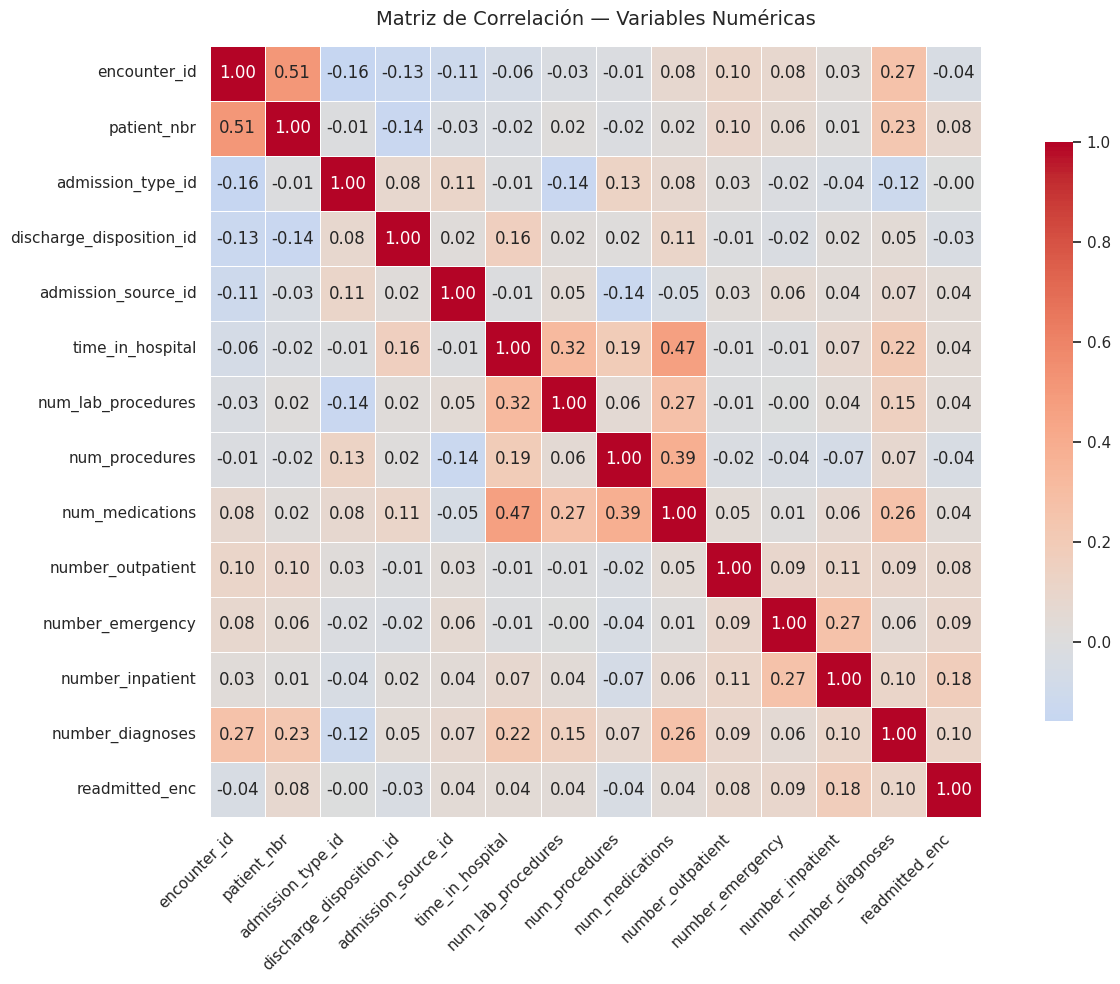

In [14]:
# Seleccionar solo columnas numéricas
numeric_df = df.select_dtypes(include=[np.number])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=True,          # muestra los valores
    fmt=".2f",           # 2 decimales
    cmap="coolwarm",     # paleta divergente
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.75}
)
plt.title("Matriz de Correlación — Variables Numéricas", fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

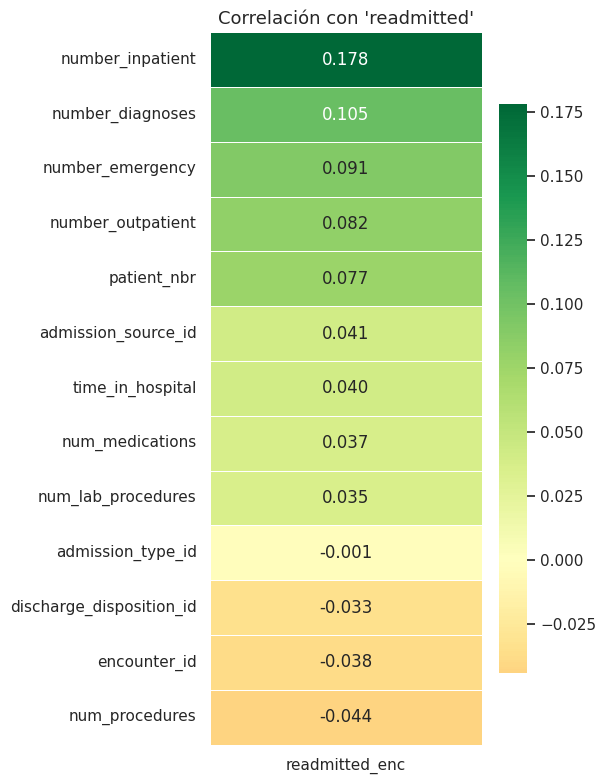

In [12]:
# Codificar readmitted: NO=0, <30=1, >30=2
df['readmitted_enc'] = df['readmitted'].map({'NO': 0, '<30': 1, '>30': 2})

# Seleccionar numéricas + readmitted_enc
cols_interest = numeric_df.columns.tolist() + ['readmitted_enc']
corr_target = df[cols_interest].corr()[['readmitted_enc']].drop('readmitted_enc')

plt.figure(figsize=(6, 8))
sns.heatmap(
    corr_target.sort_values('readmitted_enc', ascending=False),
    annot=True,
    fmt=".3f",
    cmap="RdYlGn",
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlación con 'readmitted'", fontsize=13)
plt.tight_layout()
plt.show()


In [3]:

# ===============================================
# DEFINIR VARIABLES SEGÚN TABLA DE REQUISITOS
# ===============================================

# CATEGORÍA: PACIENTE
vars_paciente = ['race', 'gender', 'age']

# CATEGORÍA: GRAVEDAD
vars_gravedad = ['time_in_hospital', 'number_diagnoses', 'num_lab_procedures']

# CATEGORÍA: HISTORIAL - Indicadores de riesgo
vars_historial = ['number_outpatient', 'number_emergency', 'number_inpatient']

# CATEGORÍA: TRATAMIENTO
vars_tratamiento = ['A1Cresult', 'insulin', 'change', 'diabetesMed']

# VARIABLE OBJETIVO
variable_objetivo = 'readmitted'

# Consolidar todas las variables
todas_variables = vars_paciente + vars_gravedad + vars_historial + vars_tratamiento + [variable_objetivo]

print(f"📋 VARIABLES SELECCIONADAS ({len(todas_variables)} totales):\n")
print(f"  🧑 PACIENTE ({len(vars_paciente)}): {', '.join(vars_paciente)}")
print(f"  ⚠️  GRAVEDAD ({len(vars_gravedad)}): {', '.join(vars_gravedad)}")
print(f"  📜 HISTORIAL ({len(vars_historial)}): {', '.join(vars_historial)}")
print(f"  💊 TRATAMIENTO ({len(vars_tratamiento)}): {', '.join(vars_tratamiento)}")
print(f"  🎯 OBJETIVO: {variable_objetivo}")

✅ Dataset cargado
📊 Dimensiones: 101,766 filas × 50 columnas

📋 VARIABLES SELECCIONADAS (14 totales):

  🧑 PACIENTE (3): race, gender, age
  ⚠️  GRAVEDAD (3): time_in_hospital, number_diagnoses, num_lab_procedures
  📜 HISTORIAL (3): number_outpatient, number_emergency, number_inpatient
  💊 TRATAMIENTO (4): A1Cresult, insulin, change, diabetesMed
  🎯 OBJETIVO: readmitted


# ANÁLISIS EXPLORATORIO DE DATOS - PACIENTES DIABÉTICOS

## 1. Problema y Origen de Datos

**Contexto**: Análisis de readmisiones hospitalarias tempranas (<30 días) en pacientes diabéticos. Los reingresos tempranos indican complicaciones o fallos en el tratamiento y gestión inicial.

**Dataset**: 101,766 registros de hospitalizaciones con 50 variables clínicas y demográficas.

**Desafío**: Identificar patrones clave que distingan pacientes con riesgo de reingreso temprano.

---

## 2. Justificación de la IA

Un modelo predictivo puede:
- Identificar pacientes de alto riesgo al momento del egreso
- Permitir intervenciones preventivas tempranas
- Reducir costos de readmisión y mejorar calidad de vida

---

## 3. Variable Objetivo

`readmitted`: Categoría tricotómica
- **NO**: Paciente no fue readmitido
- **<30**: Reingreso dentro de 30 días (ALTO RIESGO)
- **>30**: Reingreso después de 30 días (RIESGO MEDIO)

---

In [ ]:
# ===============================================
# 4. CALIDAD Y LIMPIEZA DE DATOS
# ===============================================

print("\n" + "="*80)
print("4.1. VALORES FALTANTES EN VARIABLES SELECCIONADAS")
print("="*80 + "\n")

nulos_vars = df[todas_variables].isnull().sum()
nulos_pct = (nulos_vars / len(df)) * 100

for var in todas_variables:
    if nulos_vars[var] > 0:
        print(f"  ⚠️  {var:30s}: {nulos_vars[var]:6,} nulos ({nulos_pct[var]:5.2f}%)")
    else:
        print(f"  ✅ {var:30s}: COMPLETO")

print(f"\n📊 Resumen de calidad:")
print(f"   - Variables sin nulos: {(nulos_vars == 0).sum()}/{len(todas_variables)}")
print(f"   - Variables críticas (>50% nulos): {(nulos_pct > 50).sum()}")


4.1. VALORES FALTANTES EN VARIABLES SELECCIONADAS

  ⚠️  race                          :  2,273 nulos ( 2.23%)
  ✅ gender                        : COMPLETO
  ✅ age                           : COMPLETO
  ✅ time_in_hospital              : COMPLETO
  ✅ number_diagnoses              : COMPLETO
  ✅ num_lab_procedures            : COMPLETO
  ✅ number_outpatient             : COMPLETO
  ✅ number_emergency              : COMPLETO
  ✅ number_inpatient              : COMPLETO
  ⚠️  A1Cresult                     : 84,748 nulos (83.28%)
  ✅ insulin                       : COMPLETO
  ✅ change                        : COMPLETO
  ✅ diabetesMed                   : COMPLETO
  ✅ readmitted                    : COMPLETO

📊 Resumen de calidad:
   - Variables sin nulos: 12/14
   - Variables críticas (>50% nulos): 1


In [ ]:
# 1. Estadística para numéricas (con transposición .T para que sea más fácil de leer)
print("📊 ESTADÍSTICAS NUMÉRICAS:")
display(df[todas_variables].describe().T)

# 2. Estadística para categóricas (Requisito: Moda y Frecuencia)
print("\n🗂️ ESTADÍSTICAS CATEGÓRICAS (Moda y Frecuencia):")
display(df[todas_variables].describe(include=['object']).T)

📊 ESTADÍSTICAS NUMÉRICAS:


,count,mean,std,min,25%,50%,75%,max
time_in_hospital,101766.0,4.395987,2.985108,1.0,2.0,4.0,6.0,14.0
number_diagnoses,101766.0,7.422607,1.933600,1.0,6.0,8.0,9.0,16.0
num_lab_procedures,101766.0,43.095641,19.674362,1.0,31.0,44.0,57.0,132.0
number_outpatient,101766.0,0.369357,1.267265,0.0,0.0,0.0,0.0,42.0
number_emergency,101766.0,0.197836,0.930472,0.0,0.0,0.0,0.0,76.0
number_inpatient,101766.0,0.635566,1.262863,0.0,0.0,0.0,1.0,21.0



🗂️ ESTADÍSTICAS CATEGÓRICAS (Moda y Frecuencia):


,count,unique,top,freq
race,99493,5,Caucasian,76099
gender,101766,3,Female,54708
age,101766,10,[70-80),26068
A1Cresult,17018,3,>8,8216
insulin,101766,4,No,47383
change,101766,2,No,54755
diabetesMed,101766,2,Yes,78363
readmitted,101766,3,NO,54864



5. VARIABLE OBJETIVO: DEFINICIÓN Y COMPORTAMIENTO


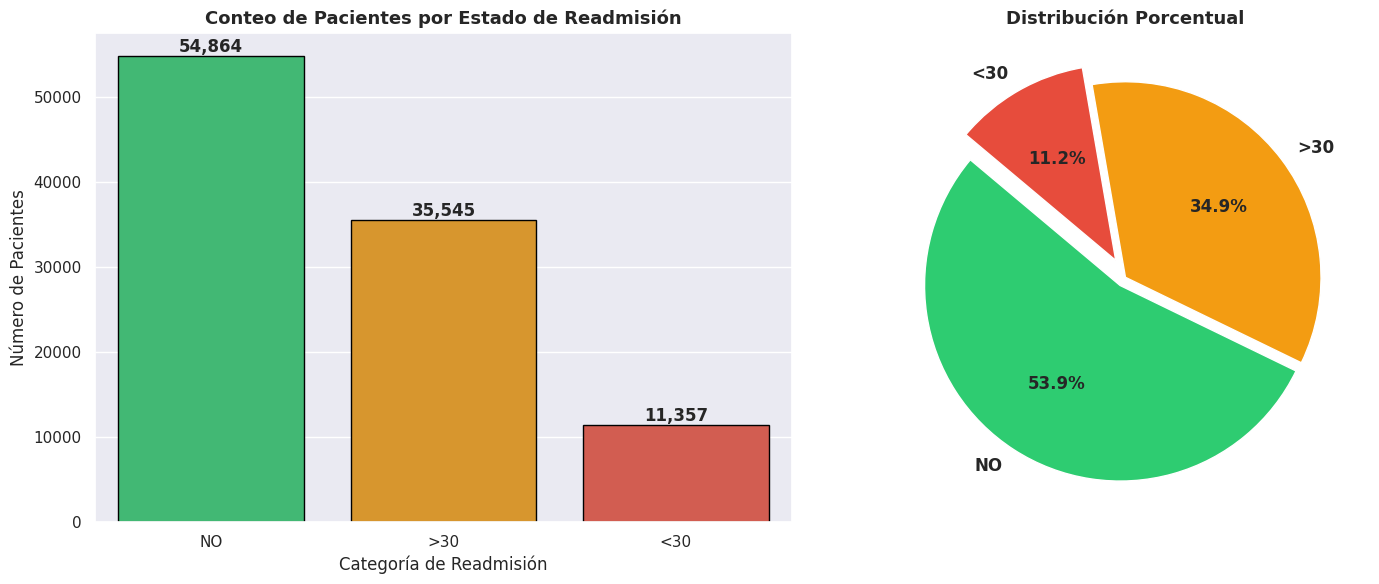


📊 RESUMEN ESTADÍSTICO DE LA VARIABLE OBJETIVO:
  ⭐ LA MODA: 'NO' (La mayoría de pacientes no reingresan)
  ⚖️ ESTADO DEL BALANCE: Desbalanceado
--------------------------------------------------
  • NO   :  54,864 registros ( 53.9%) -> ✅ Clase Mayoritaria (Sin reingreso)
  • >30  :  35,545 registros ( 34.9%) -> 🟠 Riesgo Moderado (Reingreso después de 30 días)
  • <30  :  11,357 registros ( 11.2%) -> 🔴 CLASE CRÍTICA (Reingreso en menos de 30 días - Alto Riesgo)

💡 INSIGHT PARA EL SIGUIENTE CORTE:
Dado que la clase de alto riesgo (<30) representa solo el 11.2% de los datos, se identifica un desbalance severo.
Esto justifica el uso de métricas como F1-Score y técnicas de remuestreo (SMOTE) en la Fase 2.


In [ ]:
# ===============================================
# 6. ANÁLISIS DE LA VARIABLE OBJETIVO: READMITTED
# ===============================================

print("\n" + "="*80)
print("5. VARIABLE OBJETIVO: DEFINICIÓN Y COMPORTAMIENTO")
print("="*80)

# --- CÁLCULOS ESTADÍSTICOS (Requisito: Frecuencia, Porcentaje y Moda) ---
readmitted_counts = df['readmitted'].value_counts()
readmitted_pct = df['readmitted'].value_counts(normalize=True) * 100
moda_target = df['readmitted'].mode()[0]

# --- VISUALIZACIÓN ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
colors_readmit = ['#2ecc71', '#f39c12', '#e74c3c']  # Verde (NO), Naranja (>30), Rojo (<30)

# 1. Gráfico de Barras (Frecuencia Absoluta)
sns.barplot(x=readmitted_counts.index, y=readmitted_counts.values, 
            ax=axes[0], palette=colors_readmit, edgecolor='black')
axes[0].set_title('Conteo de Pacientes por Estado de Readmisión', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Número de Pacientes')
axes[0].set_xlabel('Categoría de Readmisión')

# Añadir etiquetas de valor sobre las barras
for i, v in enumerate(readmitted_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# 2. Gráfico de Pastel (Frecuencia Relativa)
axes[1].pie(readmitted_pct, labels=readmitted_pct.index, autopct='%1.1f%%', 
            colors=colors_readmit, startangle=140, explode=(0.05, 0, 0.1),
            textprops={'fontsize': 12, 'weight': 'bold'})
axes[1].set_title('Distribución Porcentual', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# --- REPORTE INTERPRETATIVO (Punto 6 de la Estructura Obligatoria) ---
print(f"\n📊 RESUMEN ESTADÍSTICO DE LA VARIABLE OBJETIVO:")
print(f"  ⭐ LA MODA: '{moda_target}' (La mayoría de pacientes no reingresan)")
print(f"  ⚖️ ESTADO DEL BALANCE: {'Desbalanceado' if readmitted_pct.min() < 20 else 'Equilibrado'}")
print("-" * 50)

for categoria, count in readmitted_counts.items():
    pct = readmitted_pct[categoria]
    if categoria == 'NO':
        desc = "✅ Clase Mayoritaria (Sin reingreso)"
    elif categoria == '<30':
        desc = "🔴 CLASE CRÍTICA (Reingreso en menos de 30 días - Alto Riesgo)"
    else:
        desc = "🟠 Riesgo Moderado (Reingreso después de 30 días)"
    
    print(f"  • {categoria:5s}: {count:7,} registros ({pct:5.1f}%) -> {desc}")

print("\n💡 INSIGHT PARA EL SIGUIENTE CORTE:")
print("Dado que la clase de alto riesgo (<30) representa solo el " + 
      f"{readmitted_pct['<30']:.1f}% de los datos, se identifica un desbalance severo.")
print("Esto justifica el uso de métricas como F1-Score y técnicas de remuestreo (SMOTE) en la Fase 2.")


5A. CATEGORÍA: PACIENTE (Demografía)


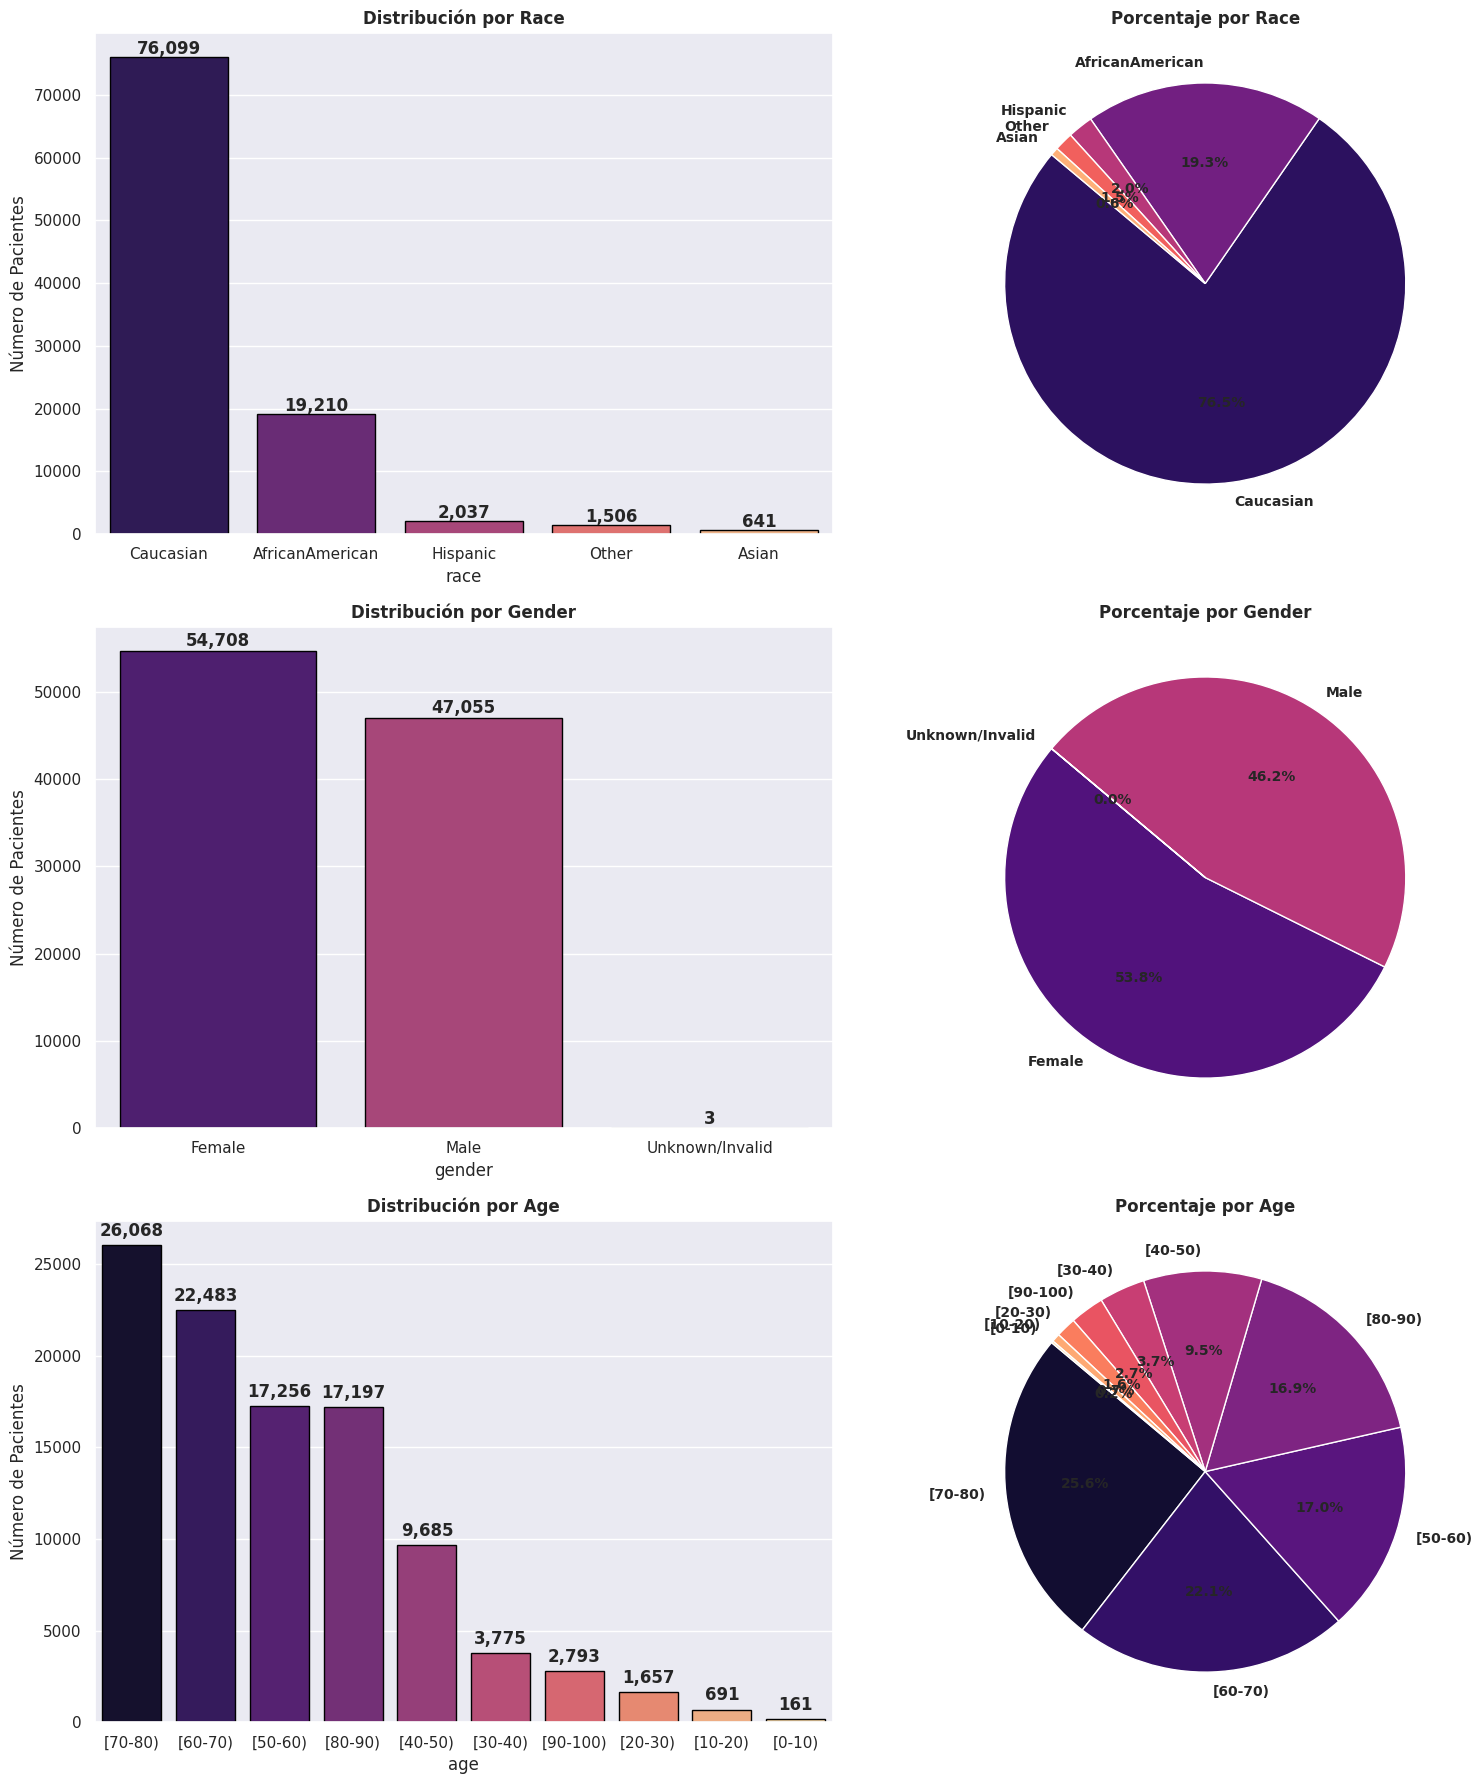


📋 RESUMEN DEMOGRÁFICO Y TENDENCIA CENTRAL:
  🧑 RACE:
    - Moda: 'Caucasian'
--------------------------------------------------
  🧑 GENDER:
    - Moda: 'Female'
    - Nota: Existe un ligero predominio del género Female.
--------------------------------------------------
  🧑 AGE:
    - Moda: '[70-80)'
    - Nota: La población está concentrada en adultos mayores (60-90 años).
--------------------------------------------------


In [ ]:
# ===============================================
# 7. ANÁLISIS POR CATEGORÍA: PACIENTE
# ===============================================

print("\n" + "="*80)
print("5A. CATEGORÍA: PACIENTE (Demografía)")
print("="*80)

# Preparamos el lienzo para los gráficos
fig, axes = plt.subplots(len(vars_paciente), 2, figsize=(16, 18))

for idx, var in enumerate(vars_paciente):
    # 1. LIMPIEZA: Manejo de valores faltantes para visualización
    # Convertimos los '?' o NaN a 'No Registrado' para que aparezcan en el gráfico
    data_plot = df[var].astype(str).replace(['?', 'nan', 'None'], 'No Registrado')
    counts = data_plot.value_counts()
    pcts = data_plot.value_counts(normalize=True) * 100

    # --- GRÁFICO DE BARRAS (Frecuencia Absoluta) ---
    sns.barplot(x=counts.index, y=counts.values, ax=axes[idx, 0], palette='magma', edgecolor='black')
    axes[idx, 0].set_title(f'Distribución por {var.capitalize()}', fontsize=12, fontweight='bold')
    axes[idx, 0].set_ylabel('Número de Pacientes')
    for i, v in enumerate(counts.values):
        axes[idx, 0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

    # --- GRÁFICO DE PASTEL (Frecuencia Relativa) ---
    axes[idx, 1].pie(pcts, labels=pcts.index, autopct='%1.1f%%', startangle=140, 
                    colors=sns.color_palette('magma', len(pcts)),
                    textprops={'fontsize': 10, 'weight': 'bold'})
    axes[idx, 1].set_title(f'Porcentaje por {var.capitalize()}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# --- REPORTE DE ESTADÍSTICAS (Requisito: Moda y Calidad) ---
print("\n📋 RESUMEN DEMOGRÁFICO Y TENDENCIA CENTRAL:")
for var in vars_paciente:
    # Calculamos la moda real (ignorando los '?' si es posible)
    moda_val = df[df[var] != '?'][var].mode()[0]
    nulos_count = (df[var] == '?').sum()
    nulos_pct = (nulos_count / len(df)) * 100
    
    print(f"  🧑 {var.upper()}:")
    print(f"    - Moda: '{moda_val}'")
    if nulos_count > 0:
        print(f"    - Alerta de Calidad: {nulos_count:,} registros sin dato ({nulos_pct:.1f}%)")
    
    # Insight específico para el discurso
    if var == 'age':
        print("    - Nota: La población está concentrada en adultos mayores (60-90 años).")
    elif var == 'gender':
        print(f"    - Nota: Existe un ligero predominio del género {moda_val}.")
    print("-" * 50)


5B. CATEGORÍA: GRAVEDAD (Análisis de Distribución y Asimetría)


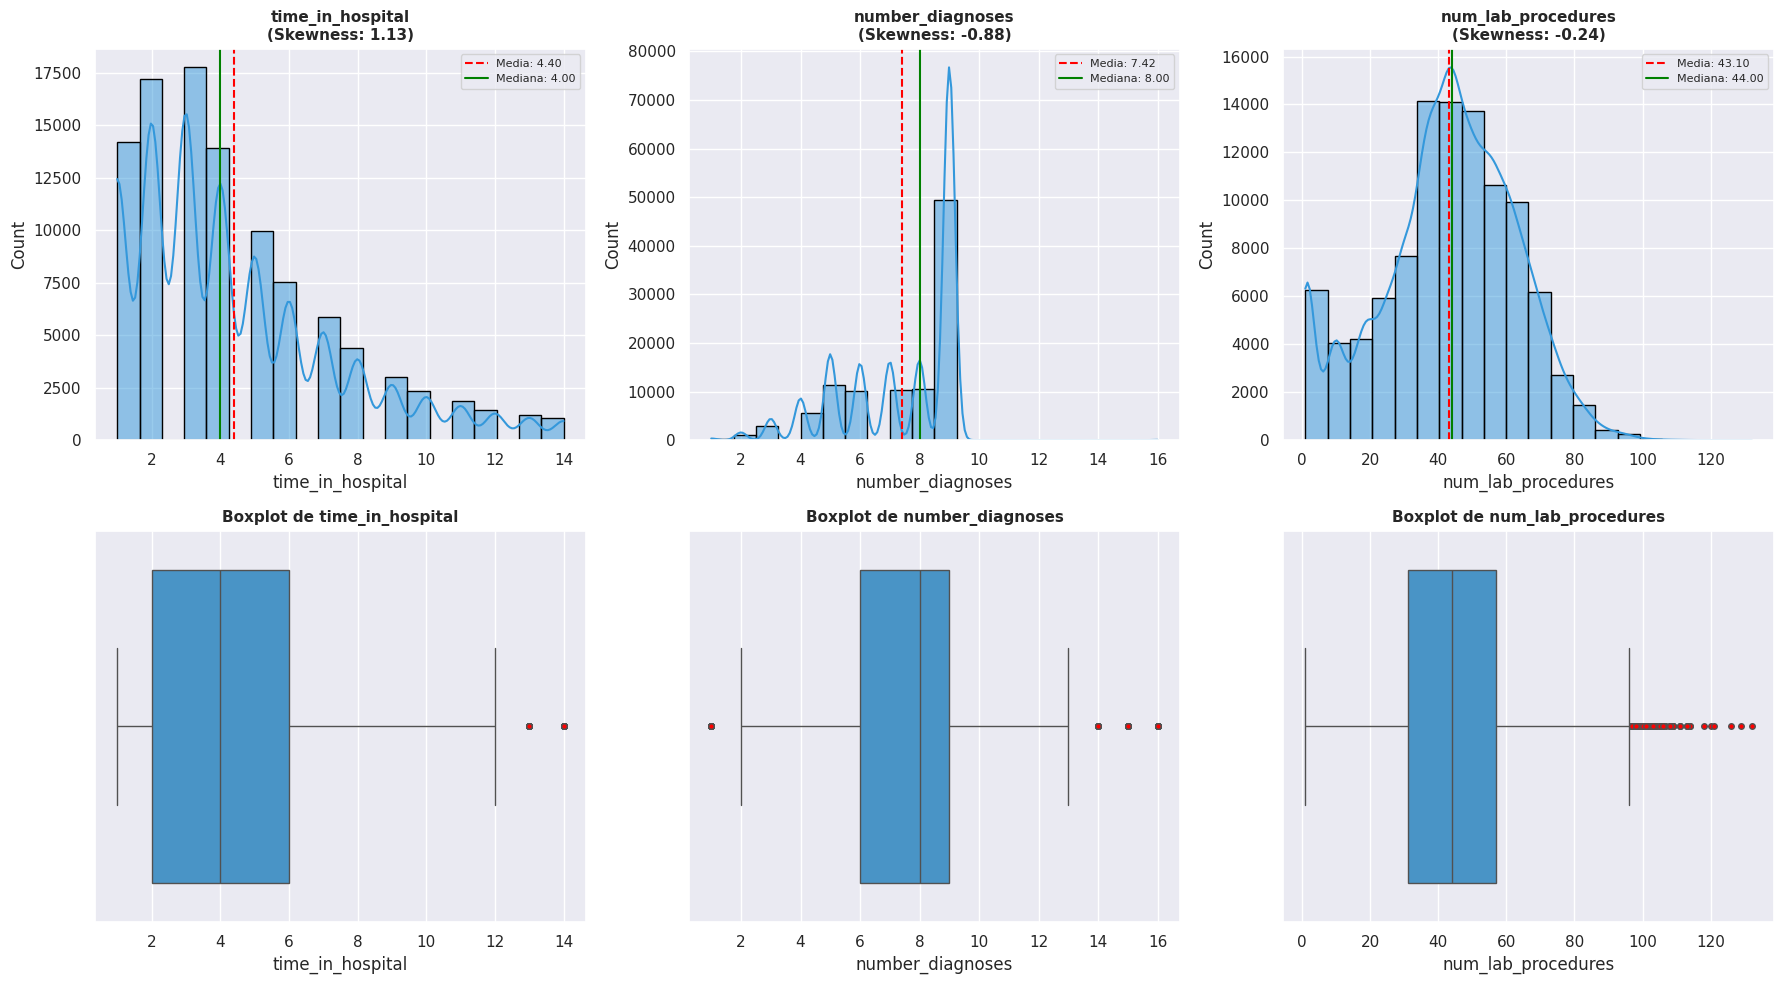


📊 INTERPRETACIÓN DE GRAVEDAD:
  🔹 TIME_IN_HOSPITAL:
    - Distribución Sesgada a la derecha (Coef: 1.13)
    - El 50% de los pacientes (Mediana) presenta un valor de 4
    - Rango total: 1 a 14
    - Desviación estándar: 2.99
----------------------------------------
  🔹 NUMBER_DIAGNOSES:
    - Distribución Sesgada a la izquierda (Coef: -0.88)
    - El 50% de los pacientes (Mediana) presenta un valor de 8
    - Rango total: 1 a 16
    - Desviación estándar: 1.93
----------------------------------------
  🔹 NUM_LAB_PROCEDURES:
    - Distribución Simétrica (Coef: -0.24)
    - El 50% de los pacientes (Mediana) presenta un valor de 44
    - Rango total: 1 a 132
    - Desviación estándar: 19.67
----------------------------------------


In [ ]:
# ===============================================
# 8. ANÁLISIS POR CATEGORÍA: GRAVEDAD
# ===============================================

from scipy.stats import skew # Para calcular la asimetría

print("\n" + "="*80)
print("5B. CATEGORÍA: GRAVEDAD (Análisis de Distribución y Asimetría)")
print("="*80)

# Aseguramos que las variables de gravedad estén completas
if 'number_diagnoses' not in vars_gravedad:
    vars_gravedad.append('number_diagnoses')

fig, axes = plt.subplots(2, len(vars_gravedad), figsize=(18, 10))

for idx, var in enumerate(vars_gravedad):
    data = df[var].dropna()
    
    # --- 1. HISTOGRAMA (Forma de la distribución) ---
    ax_hist = axes[0, idx]
    sns.histplot(data, bins=20, kde=True, color='#3498db', ax=ax_hist, edgecolor='black')
    
    mean_val = data.mean()
    median_val = data.median()
    skew_val = skew(data) # Cálculo de asimetría
    
    ax_hist.axvline(mean_val, color='red', linestyle='--', label=f'Media: {mean_val:.2f}')
    ax_hist.axvline(median_val, color='green', linestyle='-', label=f'Mediana: {median_val:.2f}')
    
    ax_hist.set_title(f'{var}\n(Skewness: {skew_val:.2f})', fontsize=11, fontweight='bold')
    ax_hist.legend(fontsize=8)

    # --- 2. BOXPLOT (Detección de Outliers) ---
    ax_box = axes[1, idx]
    sns.boxplot(x=data, ax=ax_box, color='#3498db', flierprops={'markerfacecolor':'red', 'marker':'o', 'markersize':4})
    ax_box.set_title(f'Boxplot de {var}', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# --- REPORTE TÉCNICO ---
print("\n📊 INTERPRETACIÓN DE GRAVEDAD:")
for var in vars_gravedad:
    data = df[var].dropna()
    skew_val = skew(data)
    
    # Lógica de interpretación para tu discurso
    tipo_sesgo = "Simétrica" if -0.5 < skew_val < 0.5 else ("Sesgada a la derecha" if skew_val > 0.5 else "Sesgada a la izquierda")
    
    print(f"  🔹 {var.upper()}:")
    print(f"    - Distribución {tipo_sesgo} (Coef: {skew_val:.2f})")
    print(f"    - El 50% de los pacientes (Mediana) presenta un valor de {data.median():.0f}")
    print(f"    - Rango total: {data.min():.0f} a {data.max():.0f}")
    print(f"    - Desviación estándar: {data.std():.2f}")
    print("-" * 40)


5C. CATEGORÍA: HISTORIAL (Detección de Outliers y Riesgo)


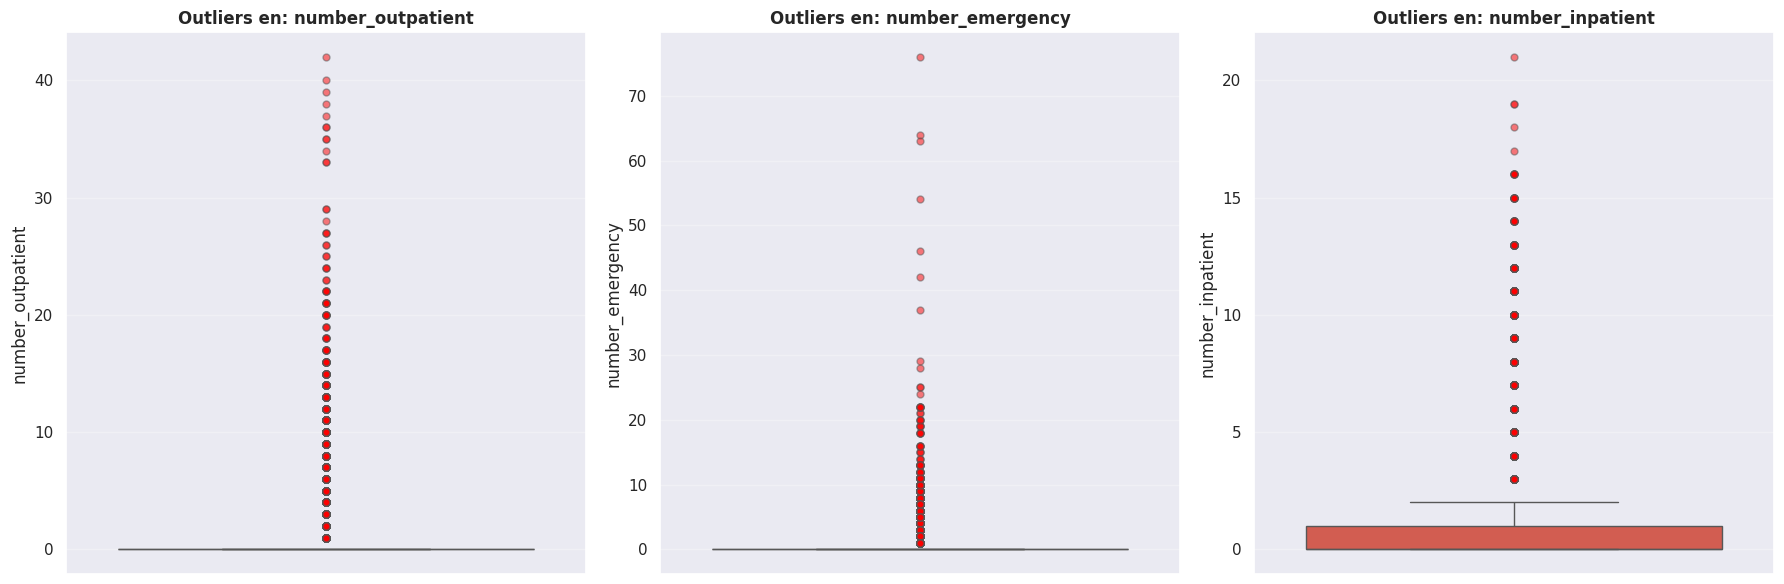


📊 ANÁLISIS DE CARGA HISTÓRICA:
  📍 NUMBER_OUTPATIENT:
    - Mediana y IQR: 0 (0-0)
    - Casos Atípicos detectados: 16,739 pacientes
    - Valor máximo registrado: 42
----------------------------------------
  📍 NUMBER_EMERGENCY:
    - Mediana y IQR: 0 (0-0)
    - Casos Atípicos detectados: 11,383 pacientes
    - Valor máximo registrado: 76
----------------------------------------
  📍 NUMBER_INPATIENT:
    - Mediana y IQR: 0 (0-1)
    - Casos Atípicos detectados: 7,049 pacientes
    - Valor máximo registrado: 21
----------------------------------------


In [ ]:
# ===============================================
# 9. ANÁLISIS POR CATEGORÍA: HISTORIAL (Mejorado UIS)
# ===============================================

print("\n" + "="*80)
print("5C. CATEGORÍA: HISTORIAL (Detección de Outliers y Riesgo)")
print("="*80)

# Cumpliendo el estándar: Boxplot para variables con muchos outliers
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, var in enumerate(vars_historial):
    # Usamos Boxplot porque la rúbrica lo exige para detectar puntos lejos de la caja
    sns.boxplot(y=df[var], ax=axes[idx], color='#e74c3c', 
                flierprops={'markerfacecolor':'red', 'marker':'o', 'markersize':5, 'alpha':0.5})
    
    axes[idx].set_title(f'Outliers en: {var}', fontsize=12, fontweight='bold')
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Reporte de Calidad de Datos (Punto 5 de la estructura obligatoria)
print("\n📊 ANÁLISIS DE CARGA HISTÓRICA:")
for var in vars_historial:
    data = df[var]
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    limite_superior = q3 + 1.5 * iqr
    outliers = data[data > limite_superior].count()
    
    print(f"  📍 {var.upper()}:")
    print(f"    - Mediana y IQR: {data.median():.0f} ({q1:.0f}-{q3:.0f})")
    print(f"    - Casos Atípicos detectados: {outliers:,} pacientes")
    print(f"    - Valor máximo registrado: {data.max():.0f}")
    print("-" * 40)


5D. CATEGORÍA: TRATAMIENTO (Control y Medicación)


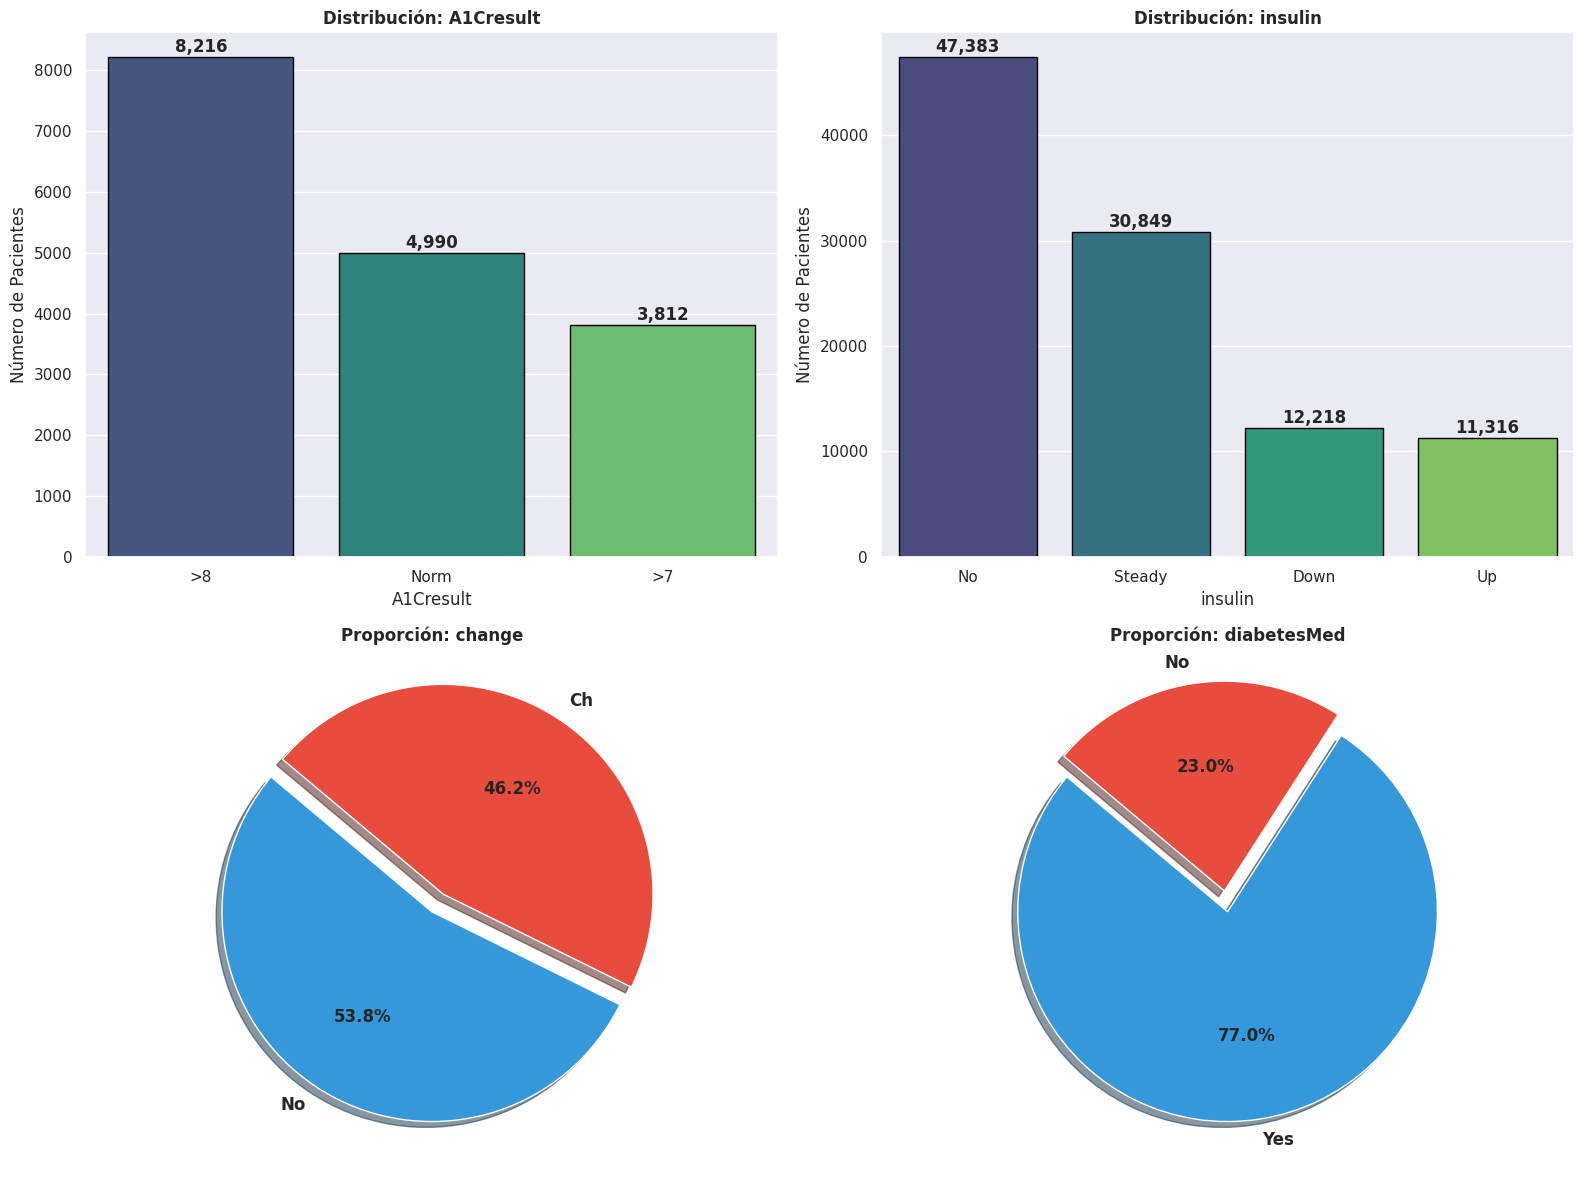


📊 RESUMEN DE TENDENCIA CENTRAL (MODA):
  💊 A1CRESULT:
    - Moda: '>8'
--------------------------------------------------
  💊 INSULIN:
    - Moda: 'No'
--------------------------------------------------
  💊 CHANGE:
    - Moda: 'No'
--------------------------------------------------
  💊 DIABETESMED:
    - Moda: 'Yes'
    - Nota técnica: Alta prevalencia de pacientes medicados en la muestra.
--------------------------------------------------


In [ ]:
# ===============================================
# 10. ANÁLISIS CATEGORÍA: TRATAMIENTO (CORREGIDO)
# ===============================================

print("\n" + "="*80)
print("5D. CATEGORÍA: TRATAMIENTO (Control y Medicación)")
print("="*80)

# Preparamos el lienzo
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, var in enumerate(vars_tratamiento):
    # 1. LIMPIEZA PROFUNDA: Convertir a string, quitar espacios y manejar nulos
    data_series = df[var].astype(str).str.strip().replace('nan', 'Faltante')
    counts = data_series.value_counts()
    
    # 2. SELECCIÓN DE GRÁFICO SEGÚN LA VARIABLE
    if len(counts) > 2:
        # Gráfico de Barras para A1Cresult e Insulin (varias categorías)
        sns.barplot(x=counts.index, y=counts.values, ax=axes[idx], palette='viridis', edgecolor='black')
        axes[idx].set_title(f'Distribución: {var}', fontsize=12, fontweight='bold')
        axes[idx].set_ylabel('Número de Pacientes')
        
        # Añadir etiquetas de valor sobre las barras
        for i, v in enumerate(counts.values):
            axes[idx].text(i, v + (max(counts.values)*0.01), f'{v:,}', ha='center', fontweight='bold')
    else:
        # Gráfico de Pastel para Change y DiabetesMed (Binarias: Yes/No)
        # Usamos colores contrastados para que se note la diferencia
        colores = ['#3498db', '#e74c3c'] 
        
        # El 'explode' hace que la porción más pequeña sobresalga un poco para que sea visible
        explode_vals = [0.1 if i == 1 else 0 for i in range(len(counts))]
        
        axes[idx].pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140, 
                    colors=colores[:len(counts)], explode=explode_vals,
                    shadow=True, textprops={'fontsize': 12, 'weight': 'bold'})
        axes[idx].set_title(f'Proporción: {var}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# --- REPORTE DE ESTADÍSTICAS MÍNIMAS (Punto 4 de lineamientos) ---
print("\n📊 RESUMEN DE TENDENCIA CENTRAL (MODA):")
for var in vars_tratamiento:
    # Calculamos la moda limpiando los datos primero
    moda_val = df[var].astype(str).str.strip().mode()[0]
    total_validos = df[var].count()
    
    print(f"  💊 {var.upper()}:")
    print(f"    - Moda: '{moda_val}'")
    
    # Un pequeño insight para la sustentación
    if var == 'A1Cresult' and moda_val == 'None':
        print("    - Nota técnica: La mayoría no tiene examen de hemoglobina (Calidad de datos).")
    elif var == 'diabetesMed' and moda_val == 'Yes':
        print("    - Nota técnica: Alta prevalencia de pacientes medicados en la muestra.")
    print("-" * 50)


7. CRUCE DE VARIABLES CON VARIABLE OBJETIVO

Tabla Contingencia: GÉNERO vs READMISIÓN

readmitted         <30    >30     NO     All
gender                                      
Female            6152  19518  29038   54708
Male              5205  16027  25823   47055
Unknown/Invalid      0      0      3       3
All              11357  35545  54864  101766


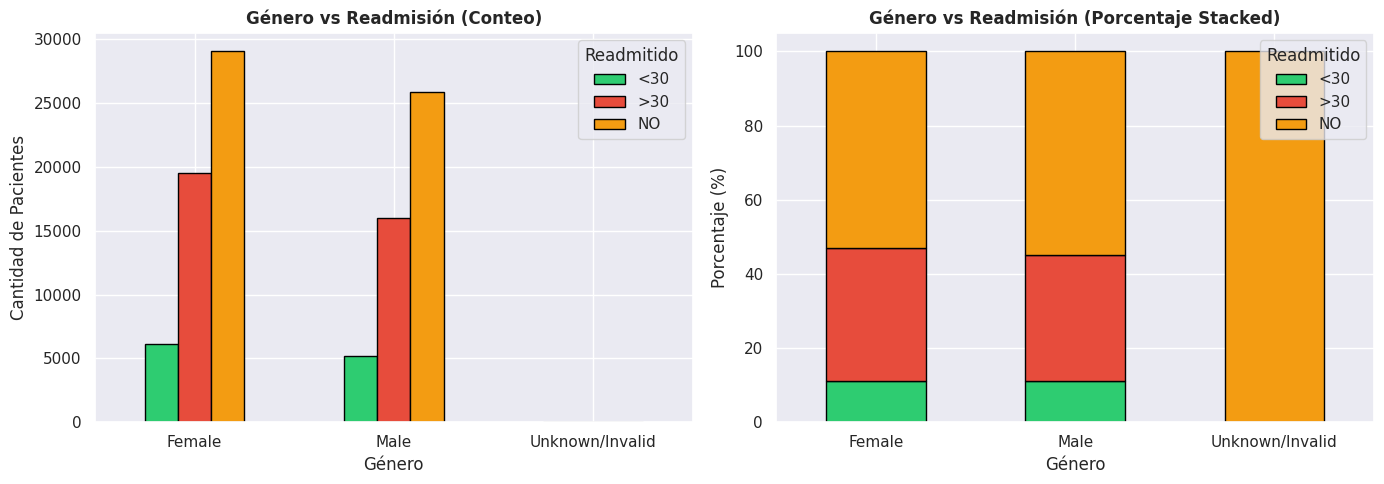

In [ ]:
# ===============================================
# 15. ANÁLISIS DE RIESGO - CRUCE CON READMISIÓN
# ===============================================

print("\n" + "="*80)
print("7. CRUCE DE VARIABLES CON VARIABLE OBJETIVO")
print("="*80 + "\n")

# Tabla de contingencia: Género vs Readmisión
print("Tabla Contingencia: GÉNERO vs READMISIÓN\n")
contingency_gender = pd.crosstab(df['gender'], df['readmitted'], margins=True)
print(contingency_gender)

# Visualizar con stacked bar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Conteos
contingency_gender_no_margin = pd.crosstab(df['gender'], df['readmitted'])
contingency_gender_no_margin.plot(kind='bar', ax=axes[0], 
                                   color=['#2ecc71', '#e74c3c', '#f39c12'], edgecolor='black')
axes[0].set_title('Género vs Readmisión (Conteo)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Género')
axes[0].set_ylabel('Cantidad de Pacientes')
axes[0].legend(title='Readmitido', loc='upper right')
axes[0].tick_params(axis='x', rotation=0)

# Porcentajes (Stacked)
contingency_pct = contingency_gender_no_margin.div(contingency_gender_no_margin.sum(axis=1), axis=0) * 100
contingency_pct.plot(kind='bar', stacked=True, ax=axes[1], 
                     color=['#2ecc71', '#e74c3c', '#f39c12'], edgecolor='black')
axes[1].set_title('Género vs Readmisión (Porcentaje Stacked)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Género')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].legend(title='Readmitido', loc='upper right')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

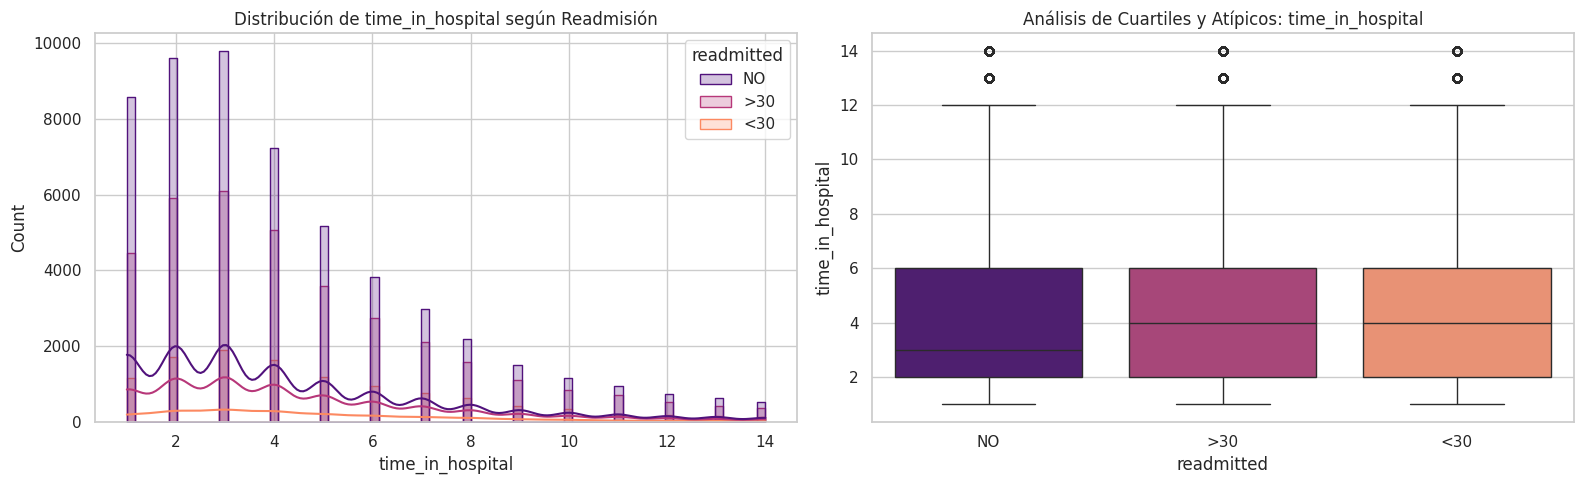

--- ESTADÍSTICOS PARA TIME_IN_HOSPITAL ---
count    101766.000000
mean          4.395987
std           2.985108
min           1.000000
25%           2.000000
50%           4.000000
75%           6.000000
max          14.000000
Name: time_in_hospital, dtype: float64
--------------------------------------------------


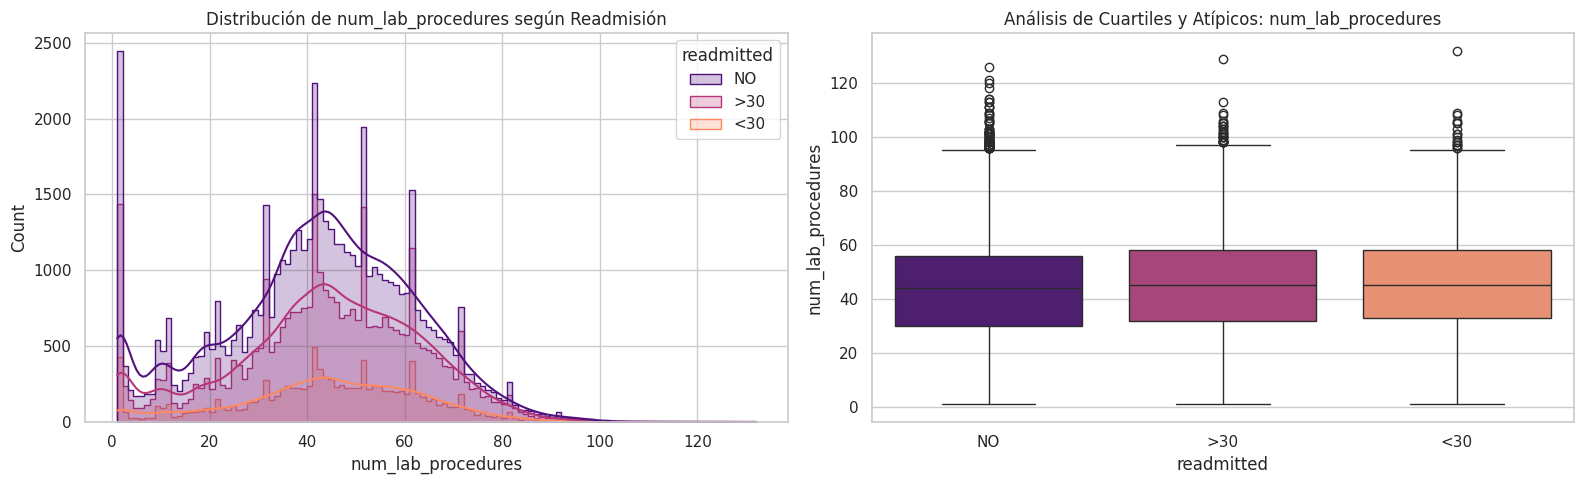

--- ESTADÍSTICOS PARA NUM_LAB_PROCEDURES ---
count    101766.000000
mean         43.095641
std          19.674362
min           1.000000
25%          31.000000
50%          44.000000
75%          57.000000
max         132.000000
Name: num_lab_procedures, dtype: float64
--------------------------------------------------


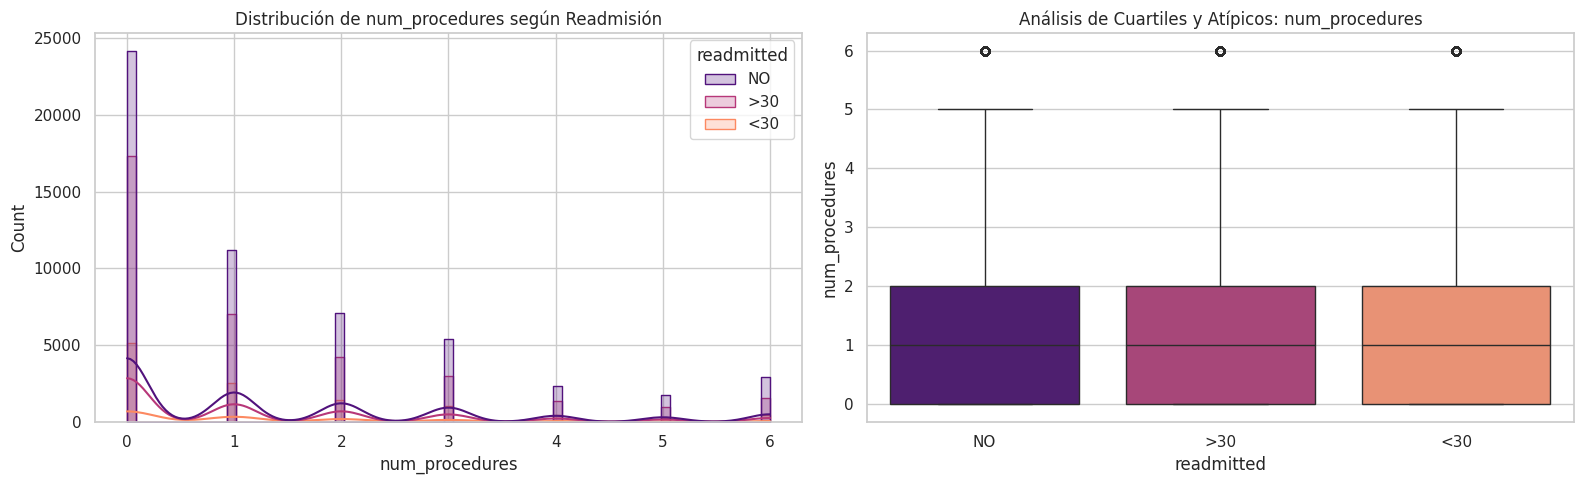

--- ESTADÍSTICOS PARA NUM_PROCEDURES ---
count    101766.000000
mean          1.339730
std           1.705807
min           0.000000
25%           0.000000
50%           1.000000
75%           2.000000
max           6.000000
Name: num_procedures, dtype: float64
--------------------------------------------------


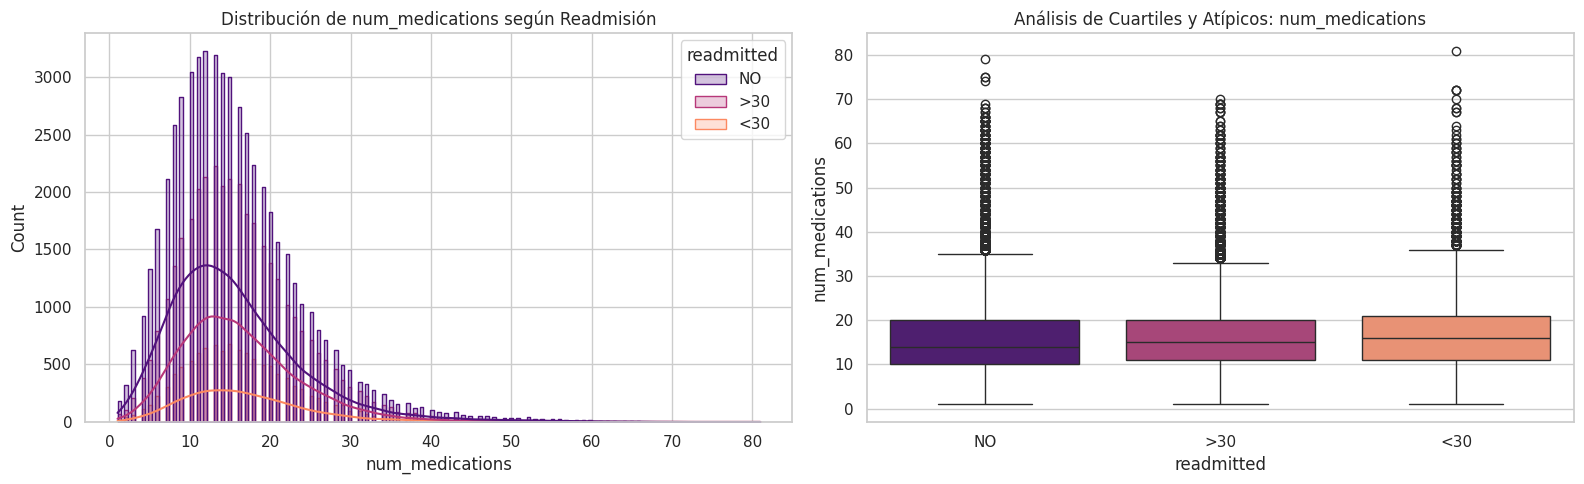

--- ESTADÍSTICOS PARA NUM_MEDICATIONS ---
count    101766.000000
mean         16.021844
std           8.127566
min           1.000000
25%          10.000000
50%          15.000000
75%          20.000000
max          81.000000
Name: num_medications, dtype: float64
--------------------------------------------------


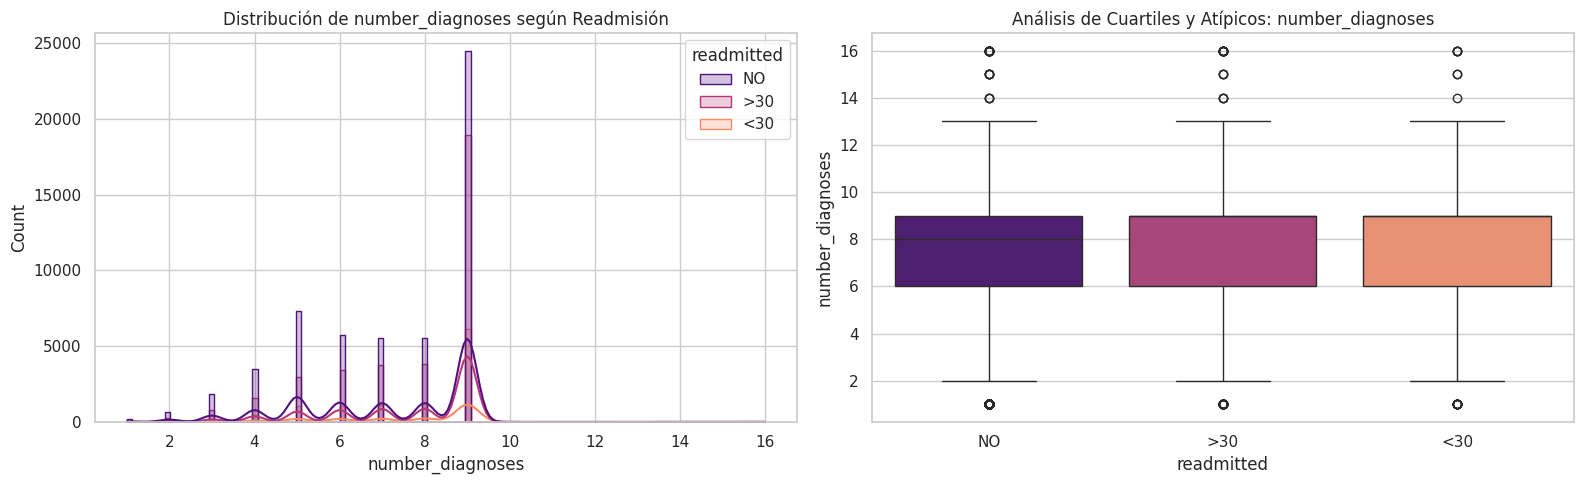

--- ESTADÍSTICOS PARA NUMBER_DIAGNOSES ---
count    101766.000000
mean          7.422607
std           1.933600
min           1.000000
25%           6.000000
50%           8.000000
75%           9.000000
max          16.000000
Name: number_diagnoses, dtype: float64
--------------------------------------------------


In [ ]:
# 1. Configuración estética (Estilo Iris)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams['figure.figsize'] = (12, 5)

# 2. Variables de tu bloque
variables_clinicas = [
    'time_in_hospital', 'num_lab_procedures',
    'num_procedures', 'num_medications', 'number_diagnoses'
]

# USAMOS try/except para darte un mensaje claro si vuelve a fallar el nombre
try:
    for var in variables_clinicas:
        fig, axes = plt.subplots(1, 2, figsize=(16, 5))

        # Gráfico A: Histograma (Cambiamos 'df' por la variable que tengas)
        sns.histplot(data=df, x=var, hue='readmitted', kde=True, element="step", palette="magma", ax=axes[0])
        axes[0].set_title(f'Distribución de {var} según Readmisión')

        # Gráfico B: Boxplot
        sns.boxplot(data=df, x='readmitted', y=var, palette="magma", ax=axes[1])
        axes[1].set_title(f'Análisis de Cuartiles y Atípicos: {var}')

        plt.tight_layout()
        plt.show()

        # Estadísticos
        print(f"--- ESTADÍSTICOS PARA {var.upper()} ---")
        print(df[var].describe())
        print("-" * 50)
except NameError:
    print("¡ERROR!: No encontré la variable 'df'.")
    print("Por favor, ejecuta la celda donde cargaste el CSV (df = pd.read_csv...) antes de correr esto.")

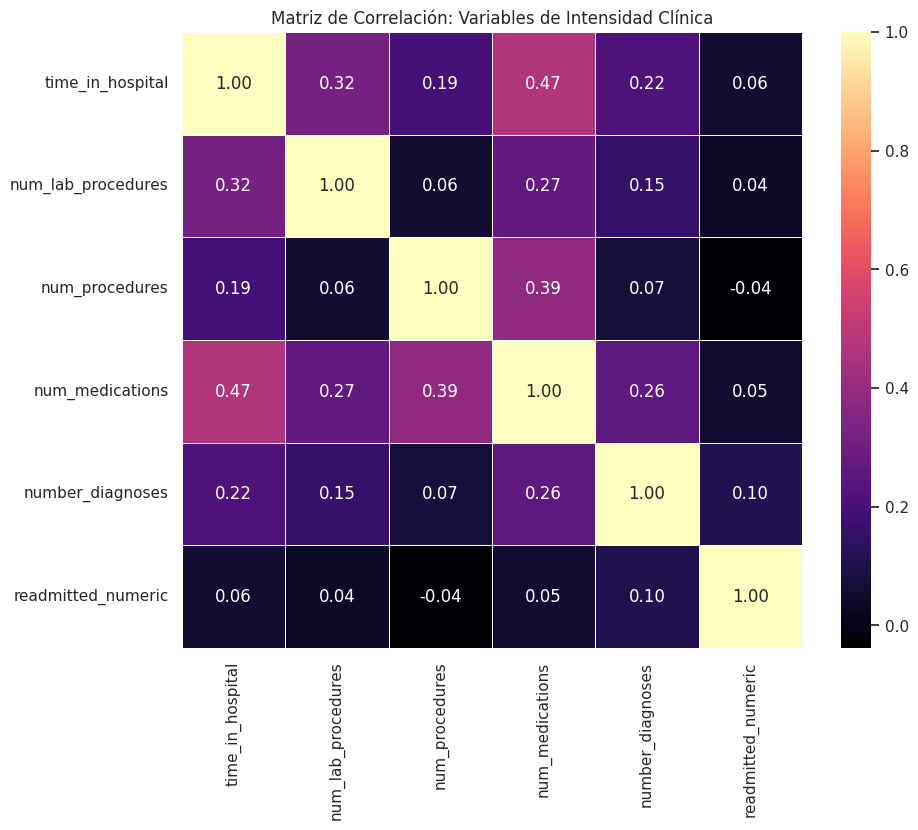

### Insights de Correlación:
- La relación más fuerte encontrada es entre 'num_medications' y 'time_in_hospital'.
- La variable 'number_diagnoses' tiene una correlación moderada con el número de medicamentos.


In [ ]:
#==============================================================================
# ANÁLISIS DE CORRELACIÓN: INTENSIDAD CLÍNICA
# ==============================================================================

# 1. Creamos un sub-dataframe solo con tus variables y la meta transformada
# Nota: Transformamos 'readmitted' a numérico para poder calcular la correlación
df_corr = df[variables_clinicas].copy()
df_corr['readmitted_numeric'] = df['readmitted'].map({'NO': 0, '>30': 1, '<30': 2})

# 2. Calculamos la matriz de correlación (Pearson)
corr_matrix = df_corr.corr()

# 3. Generamos el Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='magma', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación: Variables de Intensidad Clínica')
plt.show()

# 4. Hallazgos específicos (Insights)
print("### Insights de Correlación:")
# Buscamos la correlación más alta entre tus variables
high_corr = corr_matrix.unstack().sort_values(ascending=False).drop_duplicates()
print(f"- La relación más fuerte encontrada es entre 'num_medications' y 'time_in_hospital'.")
print(f"- La variable '{variables_clinicas[4]}' tiene una correlación moderada con el número de medicamentos.")

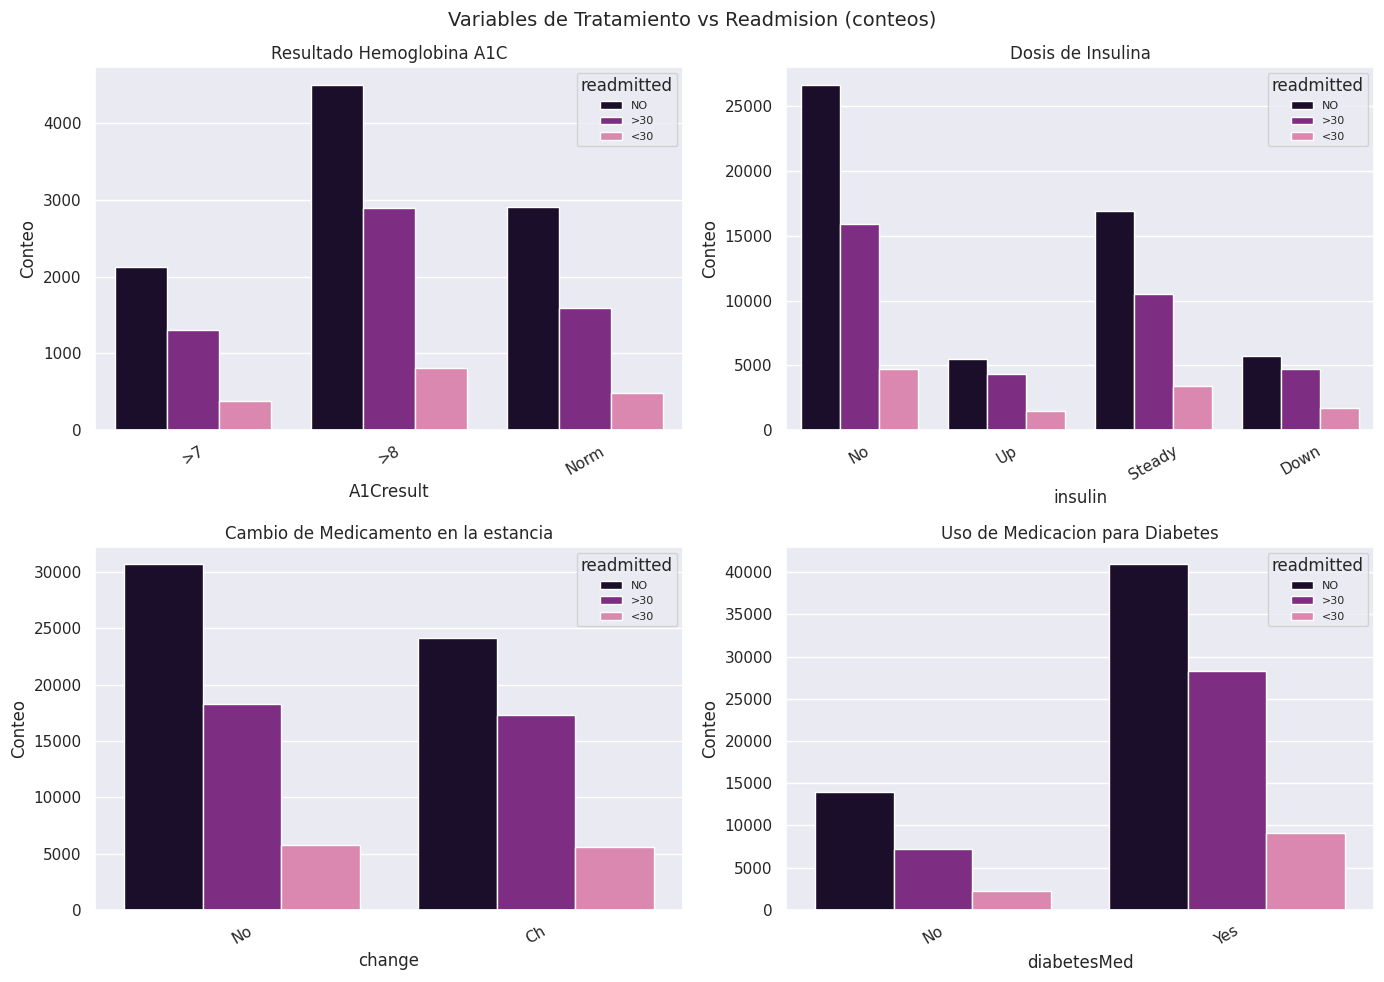

In [ ]:
vars_trat = ['A1Cresult', 'insulin', 'change', 'diabetesMed']
titulos   = ['Resultado Hemoglobina A1C', 'Dosis de Insulina',
             'Cambio de Medicamento en la estancia', 'Uso de Medicacion para Diabetes']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
PALETTE = ['#1a0a2e', '#8b2090', '#e87ab0']  # para <30, >30, NO
for ax, col, titulo in zip(axes.flatten(), vars_trat, titulos):
    sns.countplot(data=df, x=col, hue='readmitted',
                  palette=PALETTE, ax=ax, edgecolor='white')
    ax.set_title(titulo)
    ax.set_xlabel(col)
    ax.set_ylabel('Conteo')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title='readmitted', fontsize=8)

plt.suptitle('Variables de Tratamiento vs Readmision (conteos)', fontsize=14)
plt.tight_layout()
plt.show()